In [10]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')
# from plotly import express as px
# from scipy import signal as sn
# from scipy.constants import Rydberg as R
from scipy import optimize as o
plt.rcParams.update({
    "figure.figsize": (12, 9),
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 15})

In [22]:
T = pd.read_parquet('datos/cubo.parquet')
T=T.to_numpy()
# T.columns = ['T']
# T = pd.read_csv('datos/cubo.csv',names=['T'])
# T.to_parquet('datos/cubo.parquet', compression='gzip')

In [38]:
T = 250*T/np.max(T)

n = int(round(len(T)**(1/3)));n
d = 1/(n+1)

In [25]:
max_index = np.argmax(T)
max_value = T[max_index]

(max_value)
# print(max_index) 

array([0.02547014])

In [37]:
def idx_to_xyz(idx, n):
    import numpy as np
    
    # N = len(T)
    # n = int(round(N ** (1/3)))
    
    k = idx // (n**2)
    rest = idx % (n**2)
    
    j = rest // n
    i = rest % n
    
    delta = 1 / (n + 1)
    
    x = (i + 1) * delta
    y = (j + 1) * delta
    z = (k + 1) * delta
    
    return x, y, z
idx_to_xyz(max_value,n)

(array([0.01005363]), array([0.00980392]), array([0.00980392]))

In [ ]:


mid = int(1/(2*d))   # ≈ 128

i = j = k = mid

idx_i = lambda i: i + n*(j-1) + n**2*(k-1)
idx_j = lambda j: i + n*(j-1) + n**2*(k-1)
idx_k = lambda k: i + n*(j-1) + n**2*(k-1)

T_x = np.ones(n)
T_y = np.ones(n)
T_z = np.ones(n)

# (x, 1/2, 1/2)
for ii in range(n):
    T_x[ii] = T[idx_i(ii+1) - 1]

# (1/2, y, 1/2)
for jj in range(n):
    T_y[jj] = T[idx_j(jj+1) - 1]

# (1/2, 1/2, z)
for kk in range(n):
    T_z[kk] = T[idx_k(kk+1) - 1]

/var/folders/qq/cq_ngt7j6bg108c_58wr44w40000gn/T/ipykernel_27080/1369139742.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_x[ii] = T[idx_i(ii+1) - 1]
/var/folders/qq/cq_ngt7j6bg108c_58wr44w40000gn/T/ipykernel_27080/1369139742.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_y[jj] = T[idx_j(jj+1) - 1]
/var/folders/qq/cq_ngt7j6bg108c_58wr44w40000gn/T/ipykernel_27080/1369139742.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_z[kk] = T[idx_k(kk+1) 

In [33]:
x = [i*d for i in range(1,n+1)]

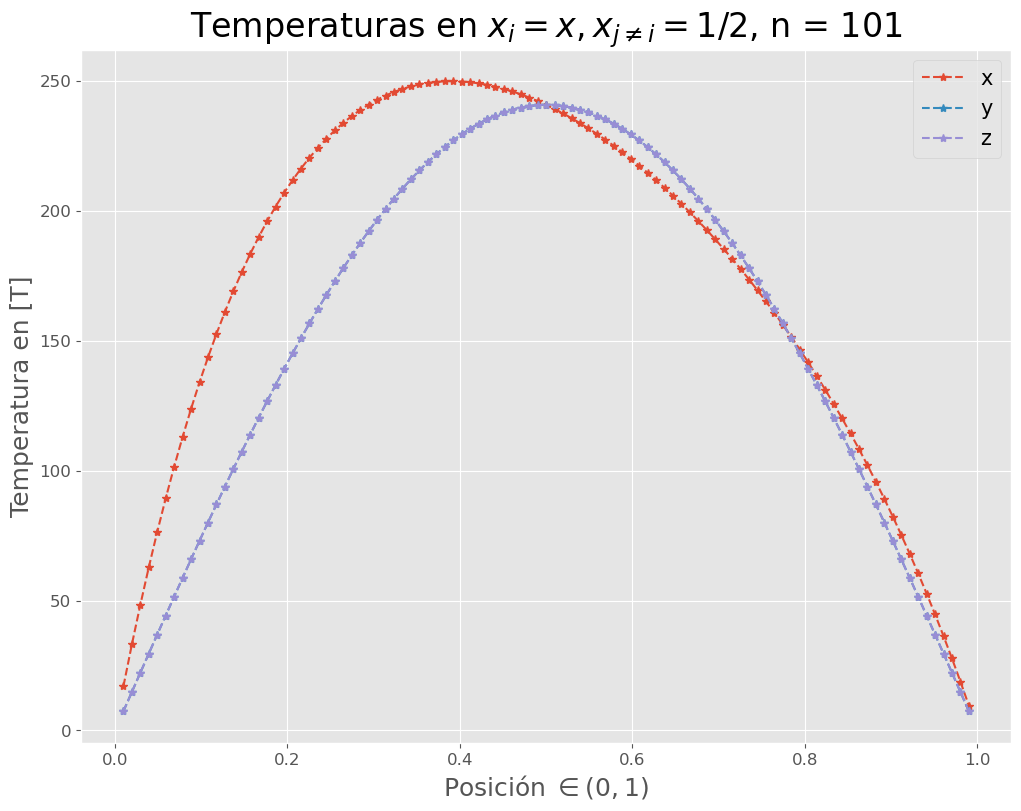

In [34]:
plt.title('Temperaturas en $x_i = x, x_{j\\neq i}=1/2$, n = 101')
plt.xlabel('Posición $\\in (0,1)$')
plt.ylabel('Temperatura en [T]')
plt.plot(x,T_x,'*--',label= 'x')
plt.plot(x,T_y,'*--',label= 'y')
plt.plot(x,T_z,'*--',label= 'z')
plt.legend()

# plt.savefig(
#     "graficos/temp_sec_transv.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
#     dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
#     bbox_inches="tight",  # recorta bordes en blanco innecesarios
#     pad_inches=0.05,   # un poquito de espacio alrededor
#     transparent=False, # True si querés fondo transparente
#     facecolor="white"  # color de fondo (se aplica si transparent=False)
# )

In [35]:
# grilla
x = np.linspace(d, 1-d, n)
y = np.linspace(d, 1-d, n)
X, Y = np.meshgrid(x, y)

# matriz de temperaturas en z = 1/2
T_xy = np.zeros((n, n))

# índice general
idx = lambda i,j,k: i + n*(j-1) + n**2*(k-1)

for i in range(1, n+1):
    for j in range(1, n+1):
        T_xy[j-1, i-1] = T['T'].iloc[idx(i,j,mid) - 1]



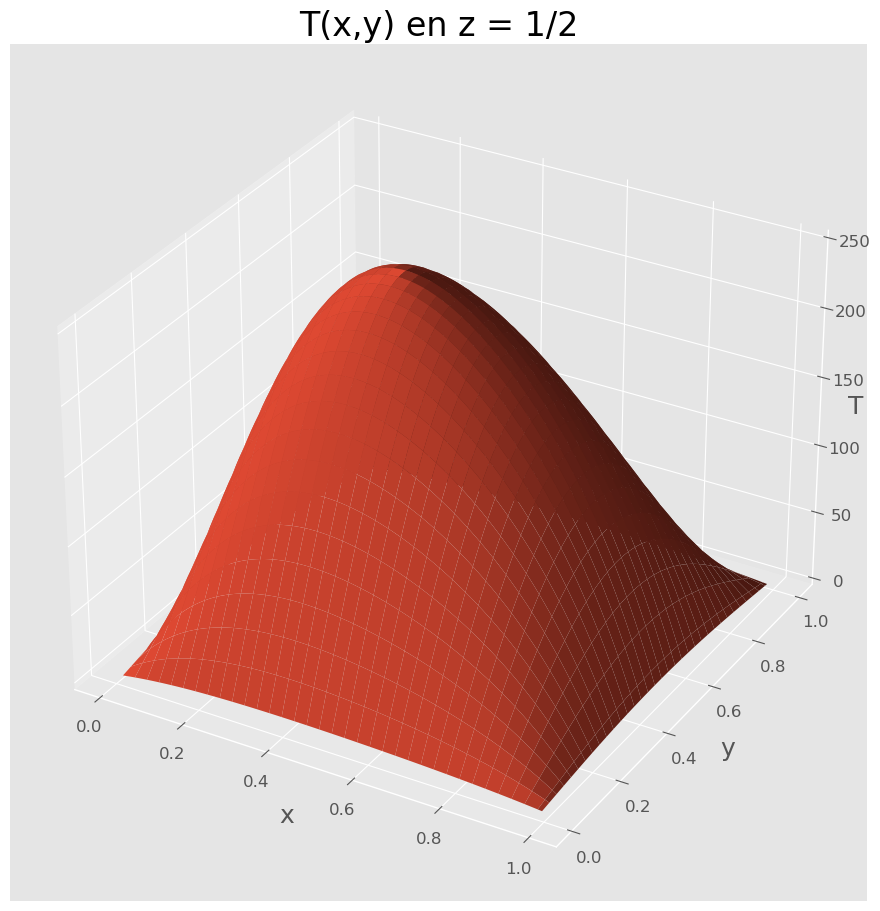

In [36]:
# gráfico 3D
fig = plt.figure(figsize=(12,9),constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.set_title('T(x,y) en z = 1/2')
# plt.title()

# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, T_xy, edgecolor='none')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('T',labelpad=-5)

# plt.show()

plt.savefig(
    "graficos/T(x,y,.5).png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
    dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
    bbox_inches="tight",  # recorta bordes en blanco innecesarios
    pad_inches=0.05,   # un poquito de espacio alrededor
    transparent=False, # True si querés fondo transparente
    facecolor="white"  # color de fondo (se aplica si transparent=False)
)

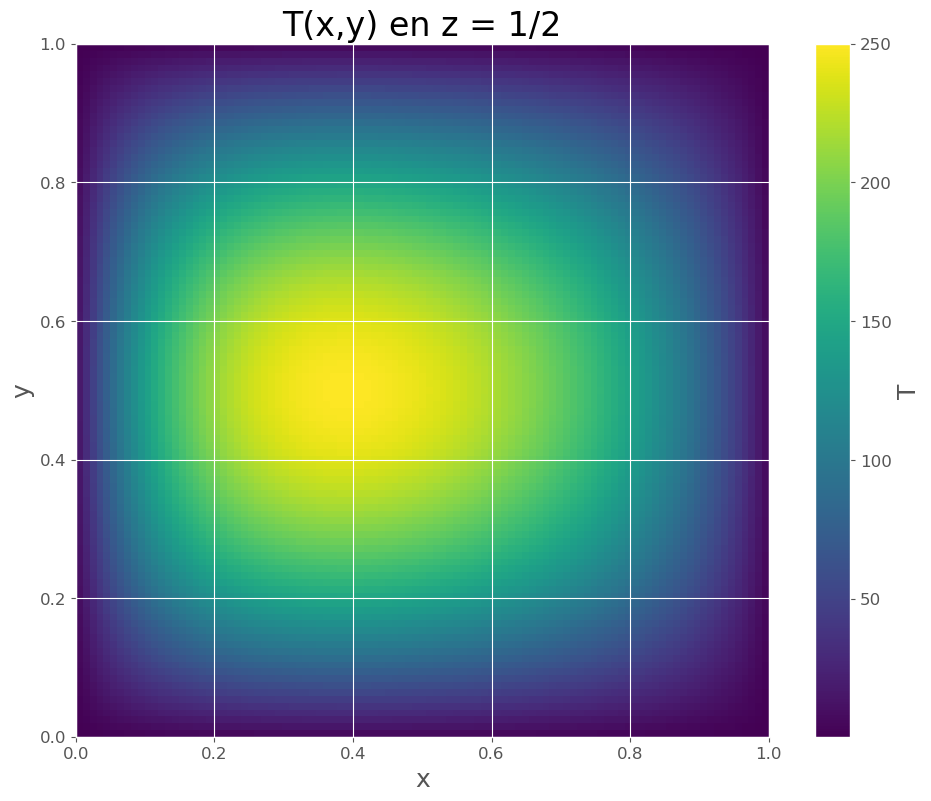

In [37]:
plt.imshow(T_xy, extent=[0,1,0,1], origin='lower')
plt.colorbar(label='T')
plt.xlabel('x')
plt.ylabel('y')
plt.title('T(x,y) en z = 1/2')

plt.savefig(
    "graficos/T(x,y,.5)_alt.png",     # nombre y formato de salida (png, pdf, svg, eps, etc.)
    dpi=300,           # resolución alta (bueno para impresión, 150–200 suficiente para pantalla)
    bbox_inches="tight",  # recorta bordes en blanco innecesarios
    pad_inches=0.05,   # un poquito de espacio alrededor
    transparent=False, # True si querés fondo transparente
    facecolor="white"  # color de fondo (se aplica si transparent=False)
)